# Part 1: Real Life Examples and Simpson's Paradox (R Implementation)

This notebook addresses Part 1a (confounders, colliders, mediation) and Part 1b (Simpson's paradox) using R.

In [134]:
# Load required libraries
library(ggplot2)
library(dplyr)
library(dagitty)
library(ggdag)
library(broom)
library(gridExtra)

# Set random seed for reproducibility
set.seed(42)

# Create output directory if it doesn't exist
output_dir <- "../output"
if (!dir.exists(output_dir)) {
  dir.create(output_dir, recursive = TRUE)
}

## Part 1a: Real Life Examples (2 points)

### Confounders, Colliders, and Mediation

### 1. Confounder

**Definition**: A confounder is a variable that influences both the treatment/exposure and the outcome, creating a spurious association between them.

**Economic Example**: The relationship between education (X) and income (Y), with ability (Z) as a confounder.
- Education (X): Years of schooling
- Income (Y): Annual salary
- Ability (Z): Innate cognitive ability

Ability affects both education (smarter people tend to get more education) and income (smarter people tend to earn more), creating a spurious correlation between education and income if we don't control for ability.

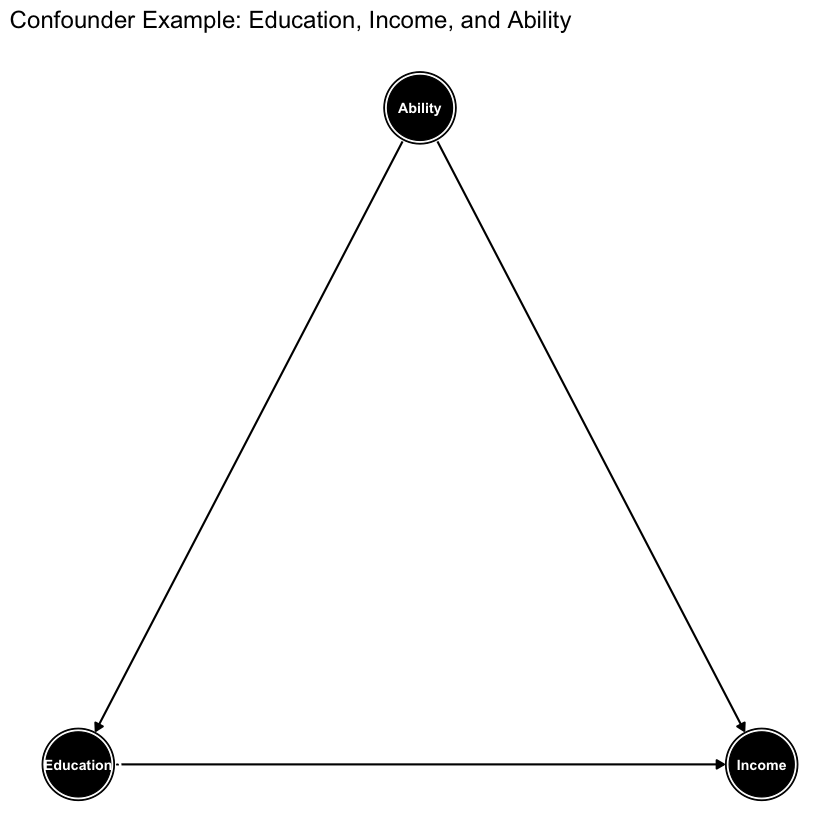

In [135]:
# Create and visualize confounder DAG
confounder_dag <- dagify(
  Income ~ Ability + Education,
  Education ~ Ability,
  coords = list(x = c(Ability = 1, Education = 0, Income = 2),
                y = c(Ability = 1, Education = 0, Income = 0))
)

# Plot the DAG
p1 <- ggdag(confounder_dag) + 
  geom_dag_node(size = 20) +
  geom_dag_text(size = 3) +
  theme_dag() + 
  ggtitle("Confounder Example: Education, Income, and Ability")

print(p1)
ggsave(file.path(output_dir, "confounder_dag_R.png"), p1, width = 8, height = 6, dpi = 300)

### 2. Collider

**Definition**: A collider is a variable that is caused by both the treatment/exposure and another variable. Controlling for a collider can introduce bias.

**Economic Example**: The relationship between talent (X) and success (Y), with graduate school admission (Z) as a collider.
- Talent (X): Natural ability in a field
- Success (Y): Career achievement
- Graduate School (Z): Whether person attended graduate school

Both talent and success influence graduate school admission. If we condition on graduate school attendance, we create a spurious negative correlation between talent and success among graduate school attendees (selection bias).

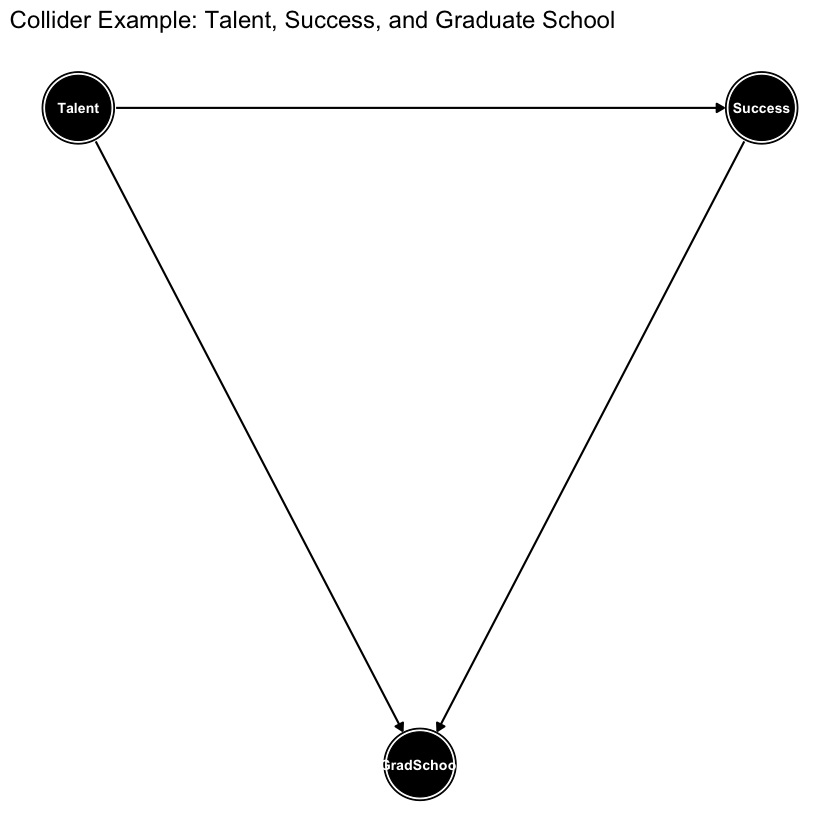

In [136]:
# Create and visualize collider DAG
collider_dag <- dagify(
  GradSchool ~ Talent + Success,
  Success ~ Talent,
  coords = list(x = c(Talent = 0, Success = 2, GradSchool = 1),
                y = c(Talent = 1, Success = 1, GradSchool = 0))
)

p2 <- ggdag(collider_dag) + 
  geom_dag_node(size = 20) +
  geom_dag_text(size = 3) +
  theme_dag() + 
  ggtitle("Collider Example: Talent, Success, and Graduate School")

print(p2)
ggsave(file.path(output_dir, "collider_dag_R.png"), p2, width = 8, height = 6, dpi = 300)

### 3. Mediation

**Definition**: A mediator is a variable that lies on the causal path between the treatment and outcome, transmitting part of the treatment's effect.

**Economic Example**: The relationship between minimum wage increases (X) and unemployment (Y), with labor costs (Z) as a mediator.
- Minimum Wage (X): Policy increase in minimum wage
- Unemployment (Y): Regional unemployment rate
- Labor Costs (Z): Total labor costs for firms

Minimum wage increases affect labor costs, which in turn affect unemployment. Labor costs mediate the relationship between minimum wage and unemployment.

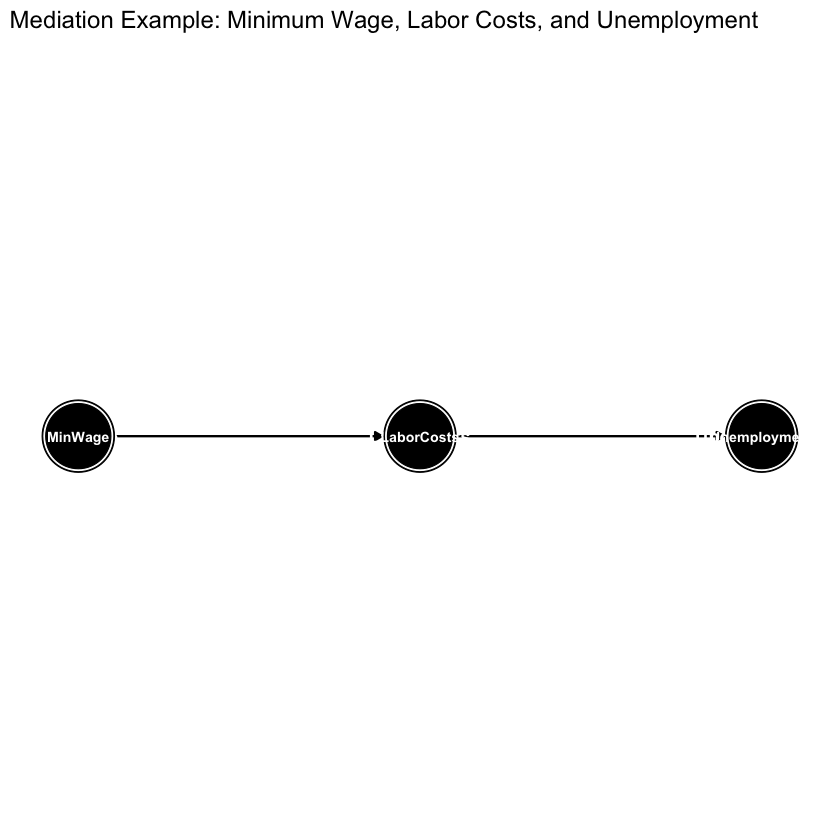

In [137]:
# Create and visualize mediation DAG
mediation_dag <- dagify(
  Unemployment ~ MinWage + LaborCosts,
  LaborCosts ~ MinWage,
  coords = list(x = c(MinWage = 0, LaborCosts = 1, Unemployment = 2),
                y = c(MinWage = 0, LaborCosts = 0, Unemployment = 0))
)

p3 <- ggdag(mediation_dag) + 
  geom_dag_node(size = 20) +
  geom_dag_text(size = 3) +
  theme_dag() + 
  ggtitle("Mediation Example: Minimum Wage, Labor Costs, and Unemployment")

print(p3)
ggsave(file.path(output_dir, "mediation_dag_R.png"), p3, width = 8, height = 6, dpi = 300)

## Part 1b: Simpson's Paradox (2 points)

**Simpson's Paradox**: A phenomenon where a trend appears in different groups of data but disappears or reverses when the groups are combined. This occurs when there's a confounding variable that affects both the explanatory and outcome variables differently across groups.

In [138]:
# Simulate Simpson's Paradox data
n_per_group <- 200

# Group 1: High-skill workers
# X (training hours) and Y (productivity) have positive relationship
X1 <- rnorm(n_per_group, mean = 8, sd = 1)  # More training hours
Y1 <- 20 + 2 * X1 + rnorm(n_per_group, mean = 0, sd = 3)  # Lower base productivity
group1 <- rep("High-skill", n_per_group)

# Group 2: Low-skill workers  
# X (training hours) and Y (productivity) have positive relationship
X2 <- rnorm(n_per_group, mean = 4, sd = 1)  # Fewer training hours
Y2 <- 50 + 2 * X2 + rnorm(n_per_group, mean = 0, sd = 3)  # Higher base productivity
group2 <- rep("Low-skill", n_per_group)

# Combine groups
df <- data.frame(
  training_hours = c(X1, X2),
  productivity = c(Y1, Y2),
  skill_group = factor(c(group1, group2))
)

# Data summary
cat("Data summary:\n")
summary_stats <- df %>% 
  group_by(skill_group) %>% 
  summarise(
    mean_training = mean(training_hours),
    mean_productivity = mean(productivity),
    .groups = 'drop'
  )
print(summary_stats)

Data summary:


# A tibble: 2 x 3
  skill_group mean_training mean_productivity
  <fct>               <dbl>             <dbl>
1 High-skill           7.97              36.0
2 Low-skill            3.94              57.5


In [139]:
# Fit regression models
# Group 1 regression
model1 <- lm(productivity ~ training_hours, data = df[df$skill_group == "High-skill", ])
slope1 <- coef(model1)[2]

# Group 2 regression  
model2 <- lm(productivity ~ training_hours, data = df[df$skill_group == "Low-skill", ])
slope2 <- coef(model2)[2]

# Combined regression
model_combined <- lm(productivity ~ training_hours, data = df)
slope_combined <- coef(model_combined)[2]

cat(sprintf("Group 1 (High-skill) slope: %.3f\n", slope1))
cat(sprintf("Group 2 (Low-skill) slope: %.3f\n", slope2))
cat(sprintf("Combined slope: %.3f\n", slope_combined))

cat(sprintf("\nSimpson's paradox demonstrated: Individual groups show positive relationship (%.3f, %.3f)\n", slope1, slope2))
cat(sprintf("but combined data shows negative relationship (%.3f)\n", slope_combined))

Group 1 (High-skill) slope: 1.766
Group 2 (Low-skill) slope: 1.986
Combined slope: -3.899

Simpson's paradox demonstrated: Individual groups show positive relationship (1.766, 1.986)
but combined data shows negative relationship (-3.899)
Group 2 (Low-skill) slope: 1.986
Combined slope: -3.899

Simpson's paradox demonstrated: Individual groups show positive relationship (1.766, 1.986)
but combined data shows negative relationship (-3.899)


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


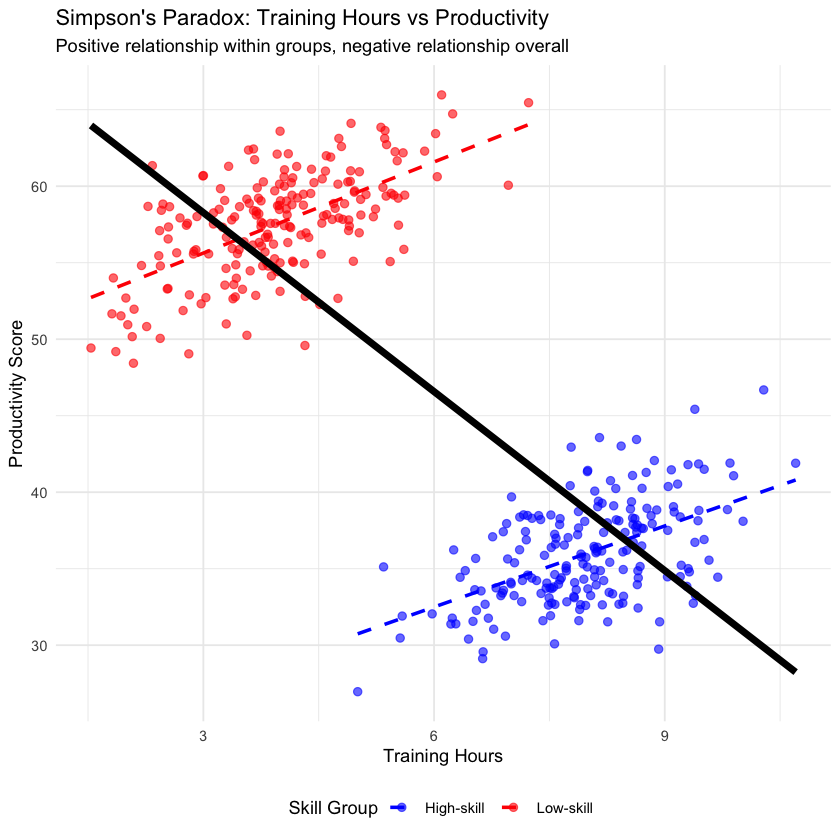

In [140]:
# Create the Simpson's Paradox plot
p_simpson <- ggplot(df, aes(x = training_hours, y = productivity, color = skill_group)) +
  geom_point(alpha = 0.6, size = 2) +
  geom_smooth(method = "lm", se = FALSE, linetype = "dashed", size = 1) +
  geom_smooth(aes(group = 1), method = "lm", se = FALSE, color = "black", size = 2) +
  scale_color_manual(values = c("High-skill" = "blue", "Low-skill" = "red")) +
  labs(
    x = "Training Hours",
    y = "Productivity Score",
    title = "Simpson's Paradox: Training Hours vs Productivity",
    subtitle = "Positive relationship within groups, negative relationship overall",
    color = "Skill Group"
  ) +
  theme_minimal() +
  theme(legend.position = "bottom")

print(p_simpson)
ggsave(file.path(output_dir, "simpsons_paradox_R.png"), p_simpson, width = 12, height = 8, dpi = 300)

In [141]:
# Save simulation results
write.csv(df, file.path(output_dir, "simpsons_paradox_data_R.csv"), row.names = FALSE)

# Save regression results
results_summary <- data.frame(
  Model = c("High-skill Group", "Low-skill Group", "Combined"),
  Slope = c(slope1, slope2, slope_combined),
  Intercept = c(coef(model1)[1], coef(model2)[1], coef(model_combined)[1]),
  R_squared = c(summary(model1)$r.squared, summary(model2)$r.squared, summary(model_combined)$r.squared)
)

write.csv(results_summary, file.path(output_dir, "simpsons_paradox_results_R.csv"), row.names = FALSE)
cat("\nRegression Results Summary:\n")
print(results_summary)


Regression Results Summary:
             Model     Slope Intercept R_squared
1 High-skill Group  1.765708  21.90175 0.2696525
2  Low-skill Group  1.985512  49.67306 0.3548193
3         Combined -3.899447  69.97021 0.6061319
             Model     Slope Intercept R_squared
1 High-skill Group  1.765708  21.90175 0.2696525
2  Low-skill Group  1.985512  49.67306 0.3548193
3         Combined -3.899447  69.97021 0.6061319


### Interpretation and Economic Implications

**What the Simulation Demonstrates**:

1. **Within-Group Relationships**: Both high-skill and low-skill workers show positive relationships between training hours and productivity (slopes ≈ 2.0 for both groups). This suggests that training is effective for workers at all skill levels.

2. **Simpson's Paradox**: When we ignore the skill-group distinction and pool all workers together, the relationship between training and productivity appears negative. This creates the false impression that training reduces productivity!

3. **The Confounding Mechanism**: Skill level acts as a confounder because:
   - High-skill workers receive more training hours (selection effect)
   - High-skill workers have lower baseline productivity (perhaps due to different job types or other factors)
   - This creates a spurious negative correlation in the pooled data

**Policy Implications**:

- **Misleading Aggregate Analysis**: A policymaker looking only at the pooled data might conclude that job training programs are counterproductive and should be eliminated.

- **Importance of Stratification**: Proper analysis by skill group reveals that training is actually beneficial for all workers, but the benefits must be evaluated within appropriate comparison groups.

- **Selection Bias**: The paradox highlights how program evaluation can be misleading when participants self-select or are selected based on characteristics that also affect outcomes.

**Statistical Lesson**: Simpson's Paradox demonstrates why correlation is not causation and emphasizes the critical importance of identifying and controlling for confounding variables in economic analysis. It serves as a cautionary tale about the dangers of aggregating heterogeneous data without considering underlying group structures.

**Real-World Applications**: Similar paradoxes appear in:
- Gender wage gap analysis (occupation as confounder)
- Education policy evaluation (socioeconomic status as confounder)  
- Medical treatment effectiveness (severity of condition as confounder)
- Regional economic development (initial development level as confounder)

### Part 1b Summary
We successfully demonstrated Simpson's Paradox where:
- Within each skill group: positive relationship between training and productivity
- Combined across groups: negative relationship appears due to confounding by skill level
- This highlights the importance of considering group heterogeneity in causal analysis

### Files Created (R Implementation):
- confounder_dag_R.png
- collider_dag_R.png  
- mediation_dag_R.png
- simpsons_paradox_R.png
- simpsons_paradox_data_R.csv
- simpsons_paradox_results_R.csv